# Fine-tuning loss curves — maskloss v2

Plots the training (and validation, if present) curves logged to
`trainer_state.json`:

- **Total loss** = `L_good + lambda * L_bad_term`
- **Pinball loss**, split into normal vs anomaly steps (`normal_loss` / `anomaly_loss`)
- **MSE**, split into normal vs anomaly steps (`mse_normal_step` / `mse_anomaly_step`)
- **Anomaly hinge-active fraction** and **learning rate** (diagnostics)

Point `RUN_DIR` at any run's output folder. Eval curves (`eval_*`,
`eval_val_*`, `eval_test_*`) are auto-detected and overlaid when the run had
validation.


In [2]:
import json, glob, os
import pandas as pd
import matplotlib.pyplot as plt

# Run to inspect. Leave RUN_DIR = None to auto-pick the most recent run folder
# (any dir containing trainer_state.json); or set it to a specific output folder.
RUN_DIR = None

if RUN_DIR is None:
    found = glob.glob("**/trainer_state.json", recursive=True) + \
            (["trainer_state.json"] if os.path.exists("trainer_state.json") else [])
    assert found, "no trainer_state.json under the current directory"
    state_path = max(set(found), key=os.path.getmtime)
else:
    state_path = os.path.join(RUN_DIR, "trainer_state.json")
assert os.path.exists(state_path), f"not found: {state_path}"
print("reading:", state_path)

with open(state_path) as f:
    hist = json.load(f)["log_history"]

df = pd.DataFrame(hist)
print(f"{len(df)} log entries, steps {int(df['step'].min())}..{int(df['step'].max())}")
print("columns:", list(df.columns))
df.tail(3)

reading: chronos2-single-stage_mtsbench_maskLossv2_v1/trainer_state.json
81 log entries, steps 50..4000
columns: ['loss', 'grad_norm', 'learning_rate', 'normal_loss', 'mse_normal_step', 'anomaly_loss', 'mse_anomaly_step', 'anomaly_active_frac', 'epoch', 'step', 'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss']


,loss,grad_norm,learning_rate,normal_loss,mse_normal_step,anomaly_loss,mse_anomaly_step,anomaly_active_frac,epoch,step,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
78,493.8209,17008.845703,4.262407e-09,17.8858,0.4164,374.1004,4.2166,0.3147,0.9875,3950,NaN,NaN,NaN,NaN,NaN
79,551.7702,4.536403,1.638990e-12,11.1102,0.2514,395.2779,4.5899,0.3597,1.0000,4000,NaN,NaN,NaN,NaN,NaN
80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000,4000,17976.8061,71.203,0.223,0.0,279.038542


## Pinball loss — normal vs anomaly steps

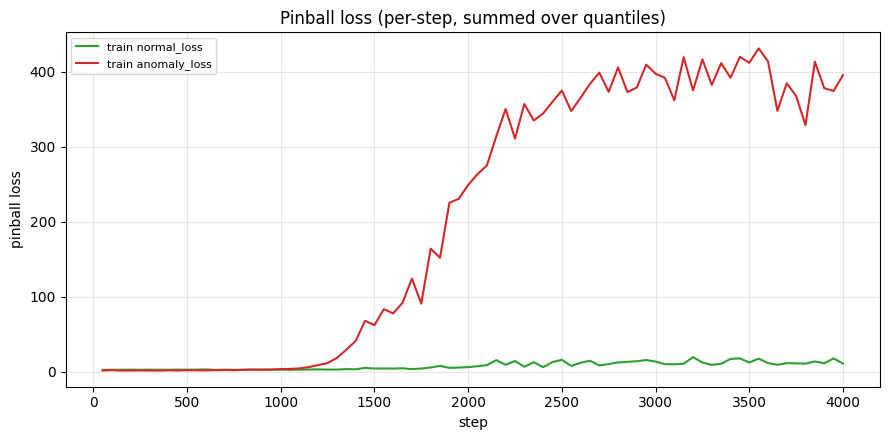

In [4]:
def plot_split(normal_col, anomaly_col, title, ylabel):
    """Plot the train normal/anomaly metric pair plus any eval variants.

    Train series use the bare column names; eval variants are the same names
    with an eval_[val_|test_] prefix (e.g. eval_val_normal_loss)."""
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for col, color in [(normal_col, "#2ca02c"), (anomaly_col, "#d62728")]:
        if col in df:
            s = df[df[col].notna()]
            if len(s):
                ax.plot(s["step"], s[col], color=color, label=f"train {col}")
        # eval variants end with the same metric name
        for c in [c for c in df.columns
                  if c.startswith("eval") and c.endswith(col)]:
            s = df[df[c].notna()]
            if len(s):
                ax.plot(s["step"], s[c], marker="o", ms=3, ls="--", label=c)
    ax.set_xlabel("step"); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

# normal_loss / anomaly_loss are the per-step pinball losses.
plot_split("normal_loss", "anomaly_loss",
           "Pinball loss (per-step, summed over quantiles)", "pinball loss")

Normal (green) should trend **down** (predict normal well); anomaly (red)
is pushed **up** toward the margin by the hinge term, so it typically sits
higher / rises early then plateaus once the margin is satisfied.

## MSE — normal vs anomaly steps

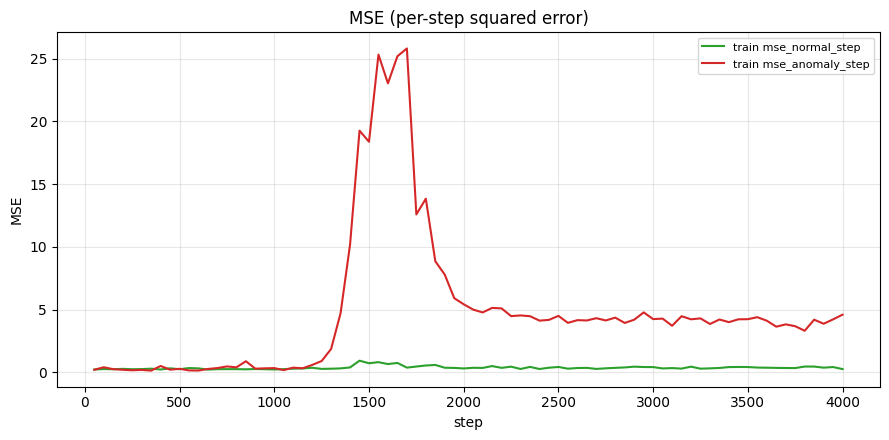

In [4]:
# mse_normal_step / mse_anomaly_step
plot_split("mse_normal_step", "mse_anomaly_step",
           "MSE (per-step squared error)", "MSE")